<div style="background:linear-gradient(135deg,#4c0519 0%,#9f1239 55%,#fb7185 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 184 &middot; Capstone 24 &middot; Natural Experiments</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Regression Discontinuity and Instrumental Variables</div>
  <div style="font-size:15px;color:#fecdd3;max-width:820px;line-height:1.6">The scholarship raises degree completion by twelve points. The obvious comparison says it lowers it by three. Two designs that assume nothing about unmeasured confounding both find the truth, by exploiting an arbitrary cutoff and a stale funding formula.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
RS, DK, LT, MUT, GD = "#9f1239", "#4c0519", "#fb7185", "#94a3b8", "#047857"
CUT = 60.0

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-regression-discontinuity-and-iv.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw   = load("Students")
plan  = load("AnalysisPlan")
truth = load("truth")
TRUE  = float(truth.loc[truth.quantity.str.contains("true effect"), "value"].iloc[0])
print("rows in the registry export:", f"{len(raw):,}")
raw.head()

rows in the registry export: 80,900


,student_id,high_school_id,family_income_k,need_index,eligible,school_places_per_100,scholarship_received,completed_degree
0,S111140,HS537,57.1,42.9,0,14.4,0,1
1,S58153,HS029,50.0,43.6,0,8.7,0,0
2,S83393,HS377,41.0,60.4,1,2.0,0,0
3,S78899,HS466,36.3,63.0,1,11.1,1,1
4,S46639,HS579,82.6,31.0,0,14.7,0,0


## Step 1 &middot; The plan, and why adjustment is not on the table

In [2]:
for line in plan.analysis_plan.fillna(""):
    print(line)

WRITTEN BEFORE THE COMPLETION DATA WERE LINKED IN.

Q QUESTION: does receiving the state scholarship raise the probability of completing a degree?

WHY NOT ADJUSTMENT. The scholarship is means tested. Recipients are poorer than non-recipients,
and family circumstances affect completion through a dozen routes nobody records. Capstone 23
showed what happens when you adjust for the routes you can see and hope about the rest.

DESIGN A: SHARP AND FUZZY REGRESSION DISCONTINUITY.
  R1 Eligibility is a deterministic function of the need index: eligible if need >= 60.0.
  R2 Students just below 60 are a credible comparison for students just above, because nothing
     else about a student changes discontinuously at an administrative threshold.
  R3 ASSUMPTION TO TEST: no manipulation of the running variable. If families could nudge the
     index across the line, the students on either side are no longer comparable. Test by
     looking for a jump in the DENSITY of the running variable at the 

## Step 2 &middot; Cleaning, and the comparison everyone would make first

In [3]:
d = raw.drop_duplicates(subset="student_id").copy()
print(f"raw rows                 {len(raw):,}")
print(f"after the duplicate export {len(d):,}")
d = d[d.need_index != 999.0]
print(f"need index assessed      {len(d):,}")
print(f"income not declared      {d.family_income_k.isna().sum()}  (kept: neither design needs it)")

r, nr = d[d.scholarship_received == 1], d[d.scholarship_received == 0]
naive = r.completed_degree.mean() - nr.completed_degree.mean()
print(f"\nreceived the scholarship   {r.completed_degree.mean():.4f}   (n = {len(r):,})")
print(f"did not receive it         {nr.completed_degree.mean():.4f}   (n = {len(nr):,})")
print(f"difference                 {naive:+.4f}")
print(f"\nthe true effect is         {TRUE:+.4f}")

raw rows                 80,900
after the duplicate export 80,000
need index assessed      79,666
income not declared      575  (kept: neither design needs it)

received the scholarship   0.4534   (n = 17,366)
did not receive it         0.4881   (n = 62,300)
difference                 -0.0347

the true effect is         +0.1200


**The naive comparison does not merely understate the effect. It has the wrong sign.** The scholarship is means tested, so it goes to students from poorer families, and family circumstances predict completion through a dozen routes nobody records. Anyone quoting that difference would report that a scholarship program harms the students who receive it.

Capstone 23 showed what happens if you respond to this by adjusting for the routes you can see. Both designs below take a different approach: instead of trying to measure away the confounding, find a piece of variation in who got the scholarship that has nothing to do with the student.

## Step 3 &middot; First look

Two designs are coming, and both of them throw most of this data away. It is worth seeing how much, and where the part they keep actually sits.

In [4]:
w9 = (d.need_index - CUT).abs() <= 9
print(f"{len(d):,} students after cleaning; the cutoff sits at {CUT:.0f}")
print(f"  need index   median {d.need_index.median():.1f}   "
      f"quartiles {d.need_index.quantile(.25):.1f} to {d.need_index.quantile(.75):.1f}   "
      f"skew {d.need_index.skew():+.3f}")
print(f"  {(d.need_index < CUT).mean():.1%} sit below the cutoff")
print(f"  a nine-point window keeps {w9.sum():,} students ({w9.mean():.1%}); "
      f"a one-point window keeps {((d.need_index-CUT).abs() <= 1).sum():,}")
print(f"  take-up among the eligible is {d.loc[d.eligible == 1, 'scholarship_received'].mean():.1%}, "
      f"and nobody ineligible received one")

79,666 students after cleaning; the cutoff sits at 60
  need index   median 52.2   quartiles 38.7 to 65.9   skew -0.073
  64.9% sit below the cutoff
  a nine-point window keeps 25,676 students (32.2%); a one-point window keeps 3,033
  take-up among the eligible is 62.0%, and nobody ineligible received one


**What this shows.** The index is close to symmetric and the only stacks in it sit at 0 and 100, where the scale is capped, forty points away from anything this design cares about. Near the cutoff it runs smoothly, which is the first thing you want from a running variable.

The shrinkage table is the number to carry forward. Almost eighty thousand students survive cleaning, and a nine-point window around the cutoff keeps a third of them. Narrow to a single point either side and three thousand are left. That is the trade the design makes, credibility bought with precision, and it is worth seeing in units of students.

The bin table is the raw material, with nothing fitted. Completion falls as need rises, all the way down the table, which is the confounding the naive comparison walked into. The one place it stops falling is the pair of bins on either side of 60.

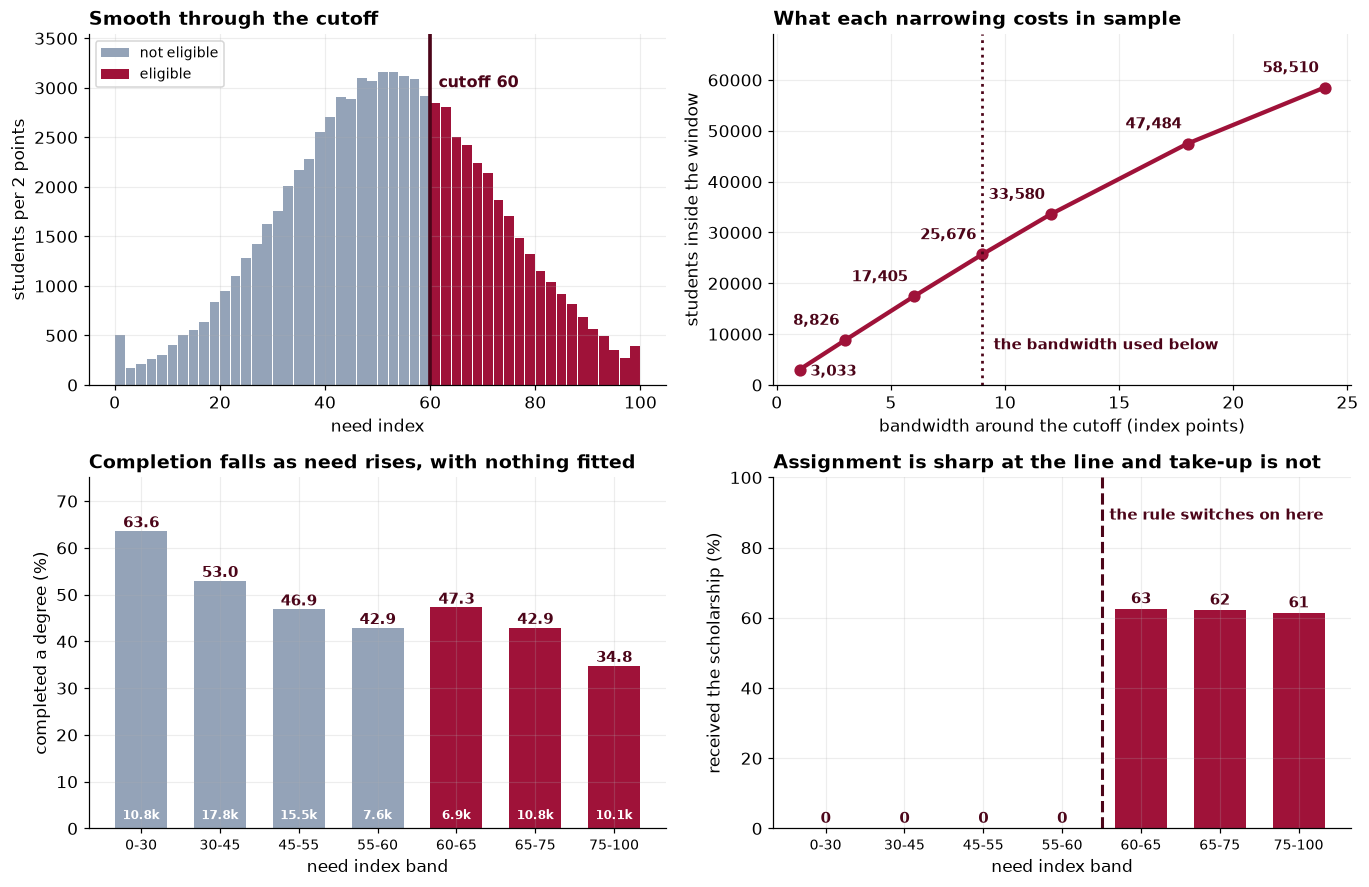

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12.6, 8.2))

ax = axes[0, 0]
bins = np.arange(0, 102, 2.0)
cnt, edges = np.histogram(d.need_index, bins=bins)
mid = (edges[:-1] + edges[1:]) / 2
ax.bar(mid[mid < CUT], cnt[mid < CUT], width=1.85, color=MUT, label="not eligible")
ax.bar(mid[mid >= CUT], cnt[mid >= CUT], width=1.85, color=RS, label="eligible")
ax.axvline(CUT, color=DK, lw=2.4)
ax.text(CUT + 1.6, cnt.max()*0.95, f"cutoff {CUT:.0f}", color=DK, fontsize=10.5, fontweight="bold")
ax.set_xlabel("need index"); ax.set_ylabel("students per 2 points")
ax.set_ylim(0, cnt.max()*1.12)
ax.set_title("Smooth through the cutoff")
ax.legend(fontsize=9, loc="upper left")

ax = axes[0, 1]
bw = [24, 18, 12, 9, 6, 3, 1]
keep = [((d.need_index - CUT).abs() <= b).sum() for b in bw]
ax.plot(bw, keep, color=RS, lw=2.8, marker="o", ms=7)
for b, k in zip(bw, keep):
    dx, dy, ha = ((7, -4, "left") if b == 1 else (-4, 10, "right"))
    ax.annotate(f"{k:,}", (b, k), textcoords="offset points", xytext=(dx, dy),
                ha=ha, fontsize=9.5, fontweight="bold", color=DK)
ax.axvline(9, color=DK, lw=1.8, ls=":")
ax.text(9.5, max(keep)*0.12, "the bandwidth used below", color=DK,
        fontsize=9.5, fontweight="bold")
ax.set_xlabel("bandwidth around the cutoff (index points)")
ax.set_ylabel("students inside the window")
ax.set_ylim(0, max(keep)*1.18)
ax.set_title("What each narrowing costs in sample")

ax = axes[1, 0]
b = pd.cut(d.need_index, bins=[0, 30, 45, 55, 60, 65, 75, 100], right=False)
g = d.groupby(b, observed=True).agg(n=("completed_degree", "size"),
                                    comp=("completed_degree", "mean"),
                                    got=("scholarship_received", "mean"))
xp = np.arange(len(g))
cols = [MUT if iv.left < CUT else RS for iv in g.index]
ax.bar(xp, g.comp.values*100, color=cols, width=0.66)
for x, v_, n_ in zip(xp, g.comp.values*100, g.n.values):
    ax.text(x, v_ + 0.8, f"{v_:.1f}", ha="center", fontsize=9.5, fontweight="bold", color=DK)
    ax.text(x, 2.0, f"{n_/1000:.1f}k", ha="center", fontsize=8, color="white", fontweight="bold")
ax.set_xticks(xp)
ax.set_xticklabels([f"{int(iv.left)}-{int(iv.right)}" for iv in g.index], fontsize=9)
ax.set_ylim(0, g.comp.max()*100*1.18)
ax.set_xlabel("need index band"); ax.set_ylabel("completed a degree (%)")
ax.set_title("Completion falls as need rises, with nothing fitted")

ax = axes[1, 1]
ax.bar(xp, g.got.values*100, color=cols, width=0.66)
for x, v_ in zip(xp, g.got.values*100):
    ax.text(x, v_ + 1.6, f"{v_:.0f}", ha="center", fontsize=9.5, fontweight="bold", color=DK)
ax.axvline(3.5, color=DK, lw=2.0, ls="--")
ax.text(3.6, 88, "the rule switches on here", color=DK, fontsize=9.5, fontweight="bold")
ax.set_xticks(xp)
ax.set_xticklabels([f"{int(iv.left)}-{int(iv.right)}" for iv in g.index], fontsize=9)
ax.set_ylim(0, 100)
ax.set_xlabel("need index band"); ax.set_ylabel("received the scholarship (%)")
ax.set_title("Assignment is sharp at the line and take-up is not")
plt.tight_layout(); plt.show()

**Top left:** the density runs through the cutoff without a step. Families cannot nudge the index, which is what Step 5 goes on to test formally, and it is worth seeing before the test rather than only after it. **Top right:** every narrowing buys comparability and pays in students. The design below keeps a window of nine points, so its answer is about students near 60 and not about the eighty thousand on the file.

**Bottom left:** completion falls steadily as need rises, all the way down the table. That is the confounding the naive comparison walked into, and the one place it stops falling is the pair of bands either side of 60. **Bottom right:** the rule itself. Nobody below the line receives a scholarship and only about three in five above it do, so the jump in the outcome will need rescaling before it means anything about the students who actually took one up.

## Step 4 &middot; Design A, the cutoff

Eligibility is a deterministic function of the need index: eligible at 60.0 or above, not eligible below. A student at 59.9 and a student at 60.1 are, in every respect anyone cares about, the same student. One of them is offered a scholarship.

In [6]:
print(f"eligible                {d.eligible.sum():,} of {len(d):,}  ({d.eligible.mean():.1%})")
print(f"received                {d.scholarship_received.sum():,}")
print(f"take-up among eligible  {d[d.eligible==1].scholarship_received.mean():.3f}")
print(f"received while not eligible: {d[(d.eligible==0)].scholarship_received.sum()}  (the rule is enforced)")

eligible                28,000 of 79,666  (35.1%)
received                17,366
take-up among eligible  0.620
received while not eligible: 0  (the rule is enforced)


## Step 5 &middot; The two assumptions an RDD can actually test

**First, no manipulation.** If families could nudge the index across the line, the students on either side stop being comparable. The signature of manipulation is a jump in the *density* of the running variable: a pile-up just above the cutoff and a hole just below.

In [7]:
h = 0.5
bins = np.arange(CUT-12, CUT+12+h, h)
cnt, _ = np.histogram(d.need_index, bins=bins)
mid = (bins[:-1] + bins[1:]) / 2

def edge_density(m, c):
    x = m - CUT
    X = np.column_stack([np.ones_like(x), x])
    return np.linalg.lstsq(X, c, rcond=None)[0][0]

L = (mid < CUT); R = (mid >= CUT)
dl, dr = edge_density(mid[L], cnt[L]), edge_density(mid[R], cnt[R])
z = (dr - dl) / np.sqrt(dl + dr)
print(f"density just below the cutoff  {dl:.1f} students per 0.5-point bin")
print(f"density just above the cutoff  {dr:.1f}")
print(f"log difference {np.log(dr/dl):+.4f}   z = {z:+.2f}")
print("\nNo discontinuity. Nobody is sorting across the line, which is what you would")
print("expect from an index computed by an agency from documents rather than self-reported.")

density just below the cutoff  749.8 students per 0.5-point bin
density just above the cutoff  727.1
log difference -0.0308   z = -0.59

No discontinuity. Nobody is sorting across the line, which is what you would
expect from an index computed by an agency from documents rather than self-reported.


**Second, covariate smoothness.** Anything measured before the scholarship should be continuous at the cutoff. If a pre-treatment characteristic jumps at 60, then something other than the rule changes there, and the design is broken.

In [8]:
def local_linear(w, col, bw):
    """Jump at the cutoff, with a triangular kernel and robust standard errors."""
    x = w.need_index.values - CUT
    y = w[col].values
    right = x >= 0
    out = {}
    for side, m in (("r", right), ("l", ~right)):
        xx, yy = x[m], y[m]
        wt = 1 - np.abs(xx)/bw
        X = np.column_stack([np.ones_like(xx), xx])
        XtWX_inv = np.linalg.inv(X.T @ (X * wt[:, None]))
        beta = XtWX_inv @ (X.T @ (yy * wt))
        res = yy - X @ beta
        meat = X.T @ (X * (wt**2 * res**2)[:, None])
        out[side] = (beta[0], (XtWX_inv @ meat @ XtWX_inv)[0, 0])
    return out["r"][0] - out["l"][0], np.sqrt(out["r"][1] + out["l"][1])

BW = 9
w = d[np.abs(d.need_index - CUT) <= BW]
wi = w.dropna(subset=["family_income_k"])
print(f"placebo checks at bandwidth {BW}, n = {len(w):,}\n")
for col, frame in [("family_income_k", wi), ("school_places_per_100", w)]:
    est, se = local_linear(frame, col, BW)
    verdict = "smooth" if abs(est/se) < 2.5 else "JUMPS - investigate"
    print(f"   {col:24s} jump {est:+8.4f}   SE {se:.4f}   z {est/se:+5.2f}   {verdict}")

placebo checks at bandwidth 9, n = 25,676

   family_income_k          jump  -0.2816   SE 0.1731   z -1.63   smooth
   school_places_per_100    jump  -0.1374   SE 0.1115   z -1.23   smooth


**Both pass.** Family income drifts by a quarter of a thousand dollars across the cutoff, which is what you would expect from noise, and the school's allocation does not move at all. Note what these checks are: they cannot prove the design works, they can only fail to find evidence that it does not. That is the most any assumption check offers.

## Step 6 &middot; The RDD estimate

Being eligible is not the same as receiving. Take-up among the eligible is 62 percent, so the jump in the outcome at the cutoff is an **intention to treat**: the effect of being *offered* the scholarship. Dividing by the jump in take-up rescales it to the effect on those whose receipt was determined by the cutoff.

In [9]:
itt, se_itt = local_linear(w, "completed_degree", BW)
jump, se_jump = local_linear(w, "scholarship_received", BW)
fuzzy = itt / jump
se_fuzzy = abs(fuzzy) * np.sqrt((se_itt/itt)**2 + (se_jump/jump)**2)

print(f"jump in completion (ITT)   {itt:+.4f}   SE {se_itt:.4f}"
      f"   95% CI [{itt-1.96*se_itt:+.4f}, {itt+1.96*se_itt:+.4f}]")
print(f"jump in take-up            {jump:+.4f}   SE {se_jump:.4f}")
print(f"\nfuzzy RDD estimate         {fuzzy:+.4f}   SE {se_fuzzy:.4f}"
      f"   95% CI [{fuzzy-1.96*se_fuzzy:+.4f}, {fuzzy+1.96*se_fuzzy:+.4f}]")
print(f"true effect                {TRUE:+.4f}")

jump in completion (ITT)   +0.0694   SE 0.0135   95% CI [+0.0428, +0.0959]
jump in take-up            +0.6257   SE 0.0094

fuzzy RDD estimate         +0.1109   SE 0.0217   95% CI [+0.0684, +0.1534]
true effect                +0.1200


**A bandwidth is a judgment, so report several.** A narrow window is more credible and less precise; a wide one is the reverse. If the estimate lurches as the window changes, that is the finding.

In [10]:
print(f"{'bw':>4}{'n':>9}{'fuzzy':>10}{'SE':>9}   95% CI")
for bw in (5, 6, 8, 9, 12, 15, 20):
    ww = d[np.abs(d.need_index - CUT) <= bw]
    a, sa = local_linear(ww, "completed_degree", bw)
    b, sb = local_linear(ww, "scholarship_received", bw)
    f = a/b; sf = abs(f)*np.sqrt((sa/a)**2 + (sb/b)**2)
    print(f"{bw:>4}{len(ww):>9,}{f:>+10.4f}{sf:>9.4f}   [{f-1.96*sf:+.4f}, {f+1.96*sf:+.4f}]")

  bw        n     fuzzy       SE   95% CI
   5   14,599   +0.1089   0.0291   [+0.0518, +0.1660]
   6   17,405   +0.1043   0.0266   [+0.0522, +0.1563]
   8   22,996   +0.1064   0.0230   [+0.0614, +0.1515]
   9   25,676   +0.1109   0.0217   [+0.0684, +0.1534]
  12   33,580   +0.1142   0.0188   [+0.0773, +0.1512]
  15   40,867   +0.1146   0.0169   [+0.0814, +0.1478]
  20   51,519   +0.1159   0.0148   [+0.0869, +0.1449]


**Stable from +0.104 to +0.116 across a fourfold change in window width, and every interval contains the truth.** That stability is part of the evidence, not decoration.

## Step 7 &middot; Design B, the instrument

The second design uses different variation entirely. Scholarship places are allocated to high schools by a formula that runs on enrollment counts three years out of date. Two otherwise identical schools can therefore have quite different allocations, for reasons that have nothing to do with this year's students, and a student at a well-allocated school is likelier to end up with a scholarship.

The analysis is restricted to eligible students, since only they can receive it.

In [11]:
e = d[d.eligible == 1].copy()
print(f"eligible students: {len(e):,}")
print(f"places per 100 at their schools: {e.school_places_per_100.min():.1f} to "
      f"{e.school_places_per_100.max():.1f}, mean {e.school_places_per_100.mean():.1f}")
q = pd.qcut(e.school_places_per_100, 5)
print("\ntake-up by quintile of the school's allocation:")
print(e.groupby(q, observed=True).scholarship_received.agg(["size","mean"]).round(3).to_string())

eligible students: 28,000
places per 100 at their schools: 2.0 to 24.9, mean 11.9

take-up by quintile of the school's allocation:
                       size   mean
school_places_per_100             
(1.999, 8.5]           5629  0.418
(8.5, 10.8]            5714  0.546
(10.8, 13.1]           5500  0.612
(13.1, 15.3]           5644  0.709
(15.3, 24.9]           5513  0.820


## Step 8 &middot; The three assumptions an instrument needs

**Relevance is testable**, and is the only one that is. Regress receipt on the instrument and look at the first stage.

In [12]:
Z = sm.add_constant(pd.DataFrame({"places": e.school_places_per_100.values,
                                  "need":   e.need_index.values}))
first = sm.OLS(e.scholarship_received.values, Z).fit()
F = first.tvalues["places"]**2
print(f"first stage: places coefficient {first.params['places']:+.5f}   SE {first.bse['places']:.5f}")
print(f"             t = {first.tvalues['places']:.1f}   F = {F:,.0f}")
print(f"\nan extra place per 100 students raises the chance of receiving by "
      f"{first.params['places']*100:.1f} points")
print(f"the usual rule of thumb is F > 10. This is {F/10:,.0f} times that.")

first stage: places coefficient +0.03508   SE 0.00068
             t = 51.8   F = 2,685

an extra place per 100 students raises the chance of receiving by 3.5 points
the usual rule of thumb is F > 10. This is 269 times that.


**Monotonicity** says more places should never make a student *less* likely to receive. It is not fully testable, and the take-up table above is consistent with it: the relationship is monotone across every quintile.

**Exclusion is not testable at all.** The allocation must affect completion *only* through receipt. That is an argument, and it is where an IV study gets attacked. Here the argument is that the formula uses stale enrollment counts, so the allocation carries no information about this year's cohort. The obvious objection is that a school's enrollment three years ago might proxy for something about the neighborhood that also affects completion. The honest response is to state the objection, note that the covariate check found no relationship between allocation and family income at the cutoff, and accept that the assumption cannot be proved.

## Step 9 &middot; The IV estimate

In [13]:
d_hat = first.fittedvalues
X2 = sm.add_constant(pd.DataFrame({"d_hat": d_hat, "need": e.need_index.values}))
second = sm.OLS(e.completed_degree.values, X2).fit()
late = second.params["d_hat"]

X_act = sm.add_constant(pd.DataFrame({"d": e.scholarship_received.values,
                                      "need": e.need_index.values}))
u = e.completed_degree.values - X_act.values @ second.params.values
s2 = (u**2).sum() / (len(e) - 3)
se_late = np.sqrt(s2 * np.linalg.inv(X2.values.T @ X2.values)[1, 1])

print(f"2SLS estimate (LATE)  {late:+.4f}   SE {se_late:.4f}"
      f"   95% CI [{late-1.96*se_late:+.4f}, {late+1.96*se_late:+.4f}]")
print(f"true effect           {TRUE:+.4f}")

ols_e = sm.OLS(e.completed_degree.values, X_act).fit()
print(f"\nOLS on the same eligible sample: {ols_e.params['d']:+.4f}")

2SLS estimate (LATE)  +0.1055   SE 0.0202   95% CI [+0.0659, +0.1451]
true effect           +0.1200

OLS on the same eligible sample: +0.1145


**Both designs land on the truth, and one detail deserves attention.** OLS restricted to the eligible sample gives +0.115, which is also close. That is not a coincidence: within the eligible group, who actually received a scholarship was largely determined by their school's allocation, which is as good as random. Restricting to the eligible removed most of the confounding by itself.

That is worth saying out loud, because it would be easy to present the IV as having rescued the analysis when a simple subgroup comparison would have done nearly as well. **The IV's contribution is that it does not depend on that being true.** Had take-up among the eligible been driven by how motivated a student was, rather than by an administrative formula, OLS on the eligible would have been badly biased and the IV would still have worked.

## Step 10 &middot; Two designs, and why their agreement counts

Capstone 23 got the same answer from matching and from weighting, and that agreement was worth nothing, because both rested on the same untestable assumption and failed together. This is a different situation.

In [14]:
rows = [
    ("naive comparison",        naive,   None,        "no unmeasured confounding, over everyone"),
    ("OLS among the eligible",  ols_e.params["d"], None, "no unmeasured confounding, within the eligible"),
    ("fuzzy RDD",               fuzzy,   se_fuzzy,    "nothing else jumps at need = 60"),
    ("instrumental variables",  late,    se_late,     "the allocation affects completion only via receipt"),
    ("the truth",               TRUE,    None,        ""),
]
print(f"{'estimator':26s}{'estimate':>10}{'95% CI':>22}   rests on")
for name, est, se, note in rows:
    ci = f"[{est-1.96*se:+.3f}, {est+1.96*se:+.3f}]" if se else ""
    print(f"{name:26s}{est:>+10.4f}{ci:>22}   {note}")

estimator                   estimate                95% CI   rests on
naive comparison             -0.0347                         no unmeasured confounding, over everyone
OLS among the eligible       +0.1145                         no unmeasured confounding, within the eligible
fuzzy RDD                    +0.1109      [+0.068, +0.153]   nothing else jumps at need = 60
instrumental variables       +0.1055      [+0.066, +0.145]   the allocation affects completion only via receipt
the truth                    +0.1200                         


The RDD assumes that nothing except eligibility changes discontinuously at 60. The IV assumes that a stale funding formula affects completion only by changing who gets a scholarship. **Neither assumption implies the other, and neither implies unconfoundedness.** They could both be wrong, but they would have to be wrong in unrelated ways and by coincidentally similar amounts. That is what makes two numbers close together into evidence.

## Step 11 &middot; The pictures

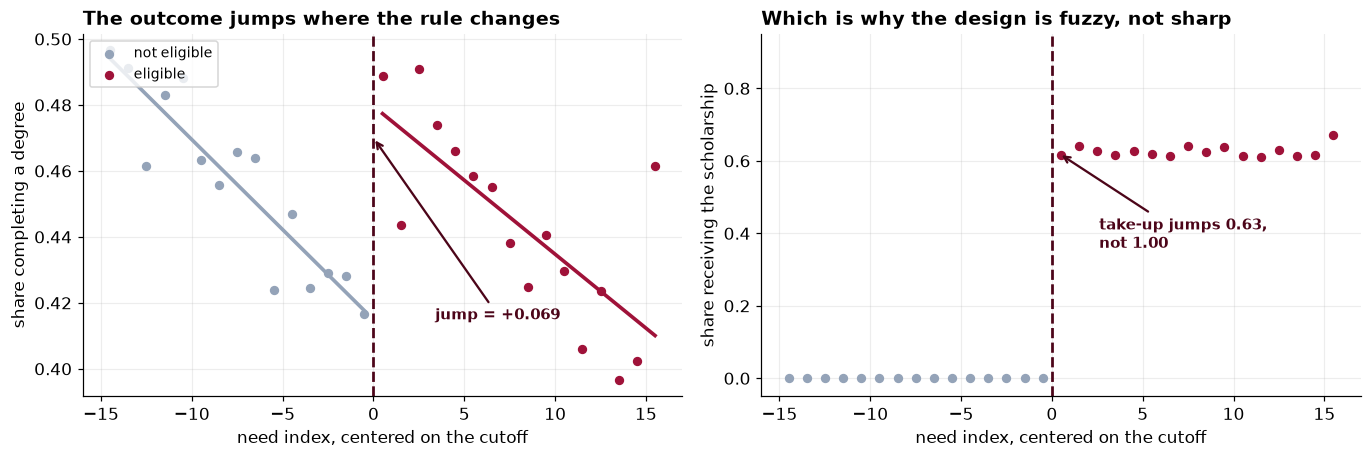

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

ax = axes[0]
bw_plot = 15
sub = d[np.abs(d.need_index - CUT) <= bw_plot].copy()
sub["bin"] = (np.floor((sub.need_index - CUT)/1.0) + 0.5)
g = sub.groupby("bin").agg(y=("completed_degree","mean"), t=("scholarship_received","mean"),
                           n=("completed_degree","size")).reset_index()
left, right = g[g.bin < 0], g[g.bin > 0]
ax.scatter(left.bin, left.y, s=26, color=MUT, zorder=3, label="not eligible")
ax.scatter(right.bin, right.y, s=26, color=RS, zorder=3, label="eligible")
for part, col in ((left, MUT), (right, RS)):
    b = np.polyfit(part.bin, part.y, 1)
    xs = np.linspace(part.bin.min(), part.bin.max(), 20)
    ax.plot(xs, np.polyval(b, xs), color=col, lw=2.4)
ax.axvline(0, color=DK, lw=1.8, ls="--")
ax.annotate(f"jump = {itt:+.3f}", xy=(0, 0.47), xytext=(3.4, 0.415), fontsize=10,
            fontweight="bold", color=DK, arrowprops=dict(arrowstyle="->", color=DK, lw=1.5))
ax.set_xlabel("need index, centered on the cutoff"); ax.set_ylabel("share completing a degree")
ax.set_title("The outcome jumps where the rule changes"); ax.legend(fontsize=9, loc="upper left")

ax = axes[1]
ax.scatter(left.bin, left.t, s=26, color=MUT, zorder=3)
ax.scatter(right.bin, right.t, s=26, color=RS, zorder=3)
ax.axvline(0, color=DK, lw=1.8, ls="--")
ax.annotate(f"take-up jumps {jump:.2f},\nnot 1.00", xy=(0.4, 0.62), xytext=(2.6, 0.36),
            fontsize=10, fontweight="bold", color=DK,
            arrowprops=dict(arrowstyle="->", color=DK, lw=1.5))
ax.set_xlabel("need index, centered on the cutoff"); ax.set_ylabel("share receiving the scholarship")
ax.set_ylim(-0.05, 0.95); ax.set_title("Which is why the design is fuzzy, not sharp")
plt.tight_layout(); plt.show()

**Left:** each dot is a one-point bin of the need index, with a straight line fitted on each side. The outcome trends downward with need, which is why a plain comparison across the cutoff would mislead, and it steps up at exactly 60. **Right:** the same picture for take-up. Eligibility does not hand out scholarships; it raises the chance of getting one from zero to about 0.63, and that is the number the intention-to-treat estimate has to be divided by.

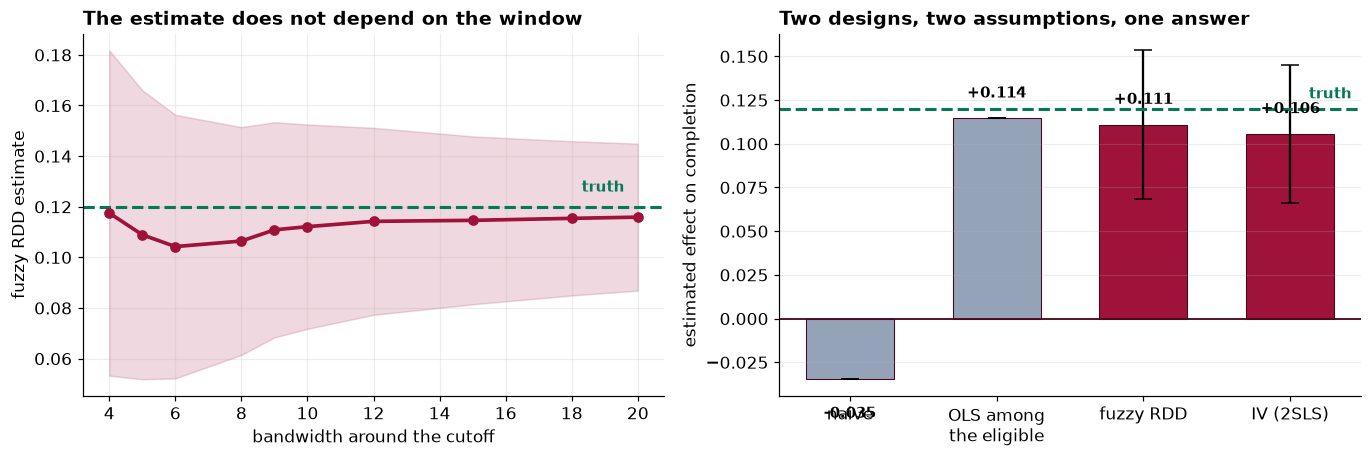

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

ax = axes[0]
bws, fs, sfs = [], [], []
for bw in (4, 5, 6, 8, 9, 10, 12, 15, 18, 20):
    ww = d[np.abs(d.need_index - CUT) <= bw]
    a, sa = local_linear(ww, "completed_degree", bw)
    b, sb = local_linear(ww, "scholarship_received", bw)
    f = a/b
    bws.append(bw); fs.append(f)
    sfs.append(abs(f)*np.sqrt((sa/a)**2 + (sb/b)**2))
fs, sfs = np.array(fs), np.array(sfs)
ax.axhline(TRUE, color=GD, lw=2, ls="--")
ax.text(19.6, TRUE+0.006, "truth", ha="right", color=GD, fontweight="bold", fontsize=9.5)
ax.fill_between(bws, fs-1.96*sfs, fs+1.96*sfs, color=RS, alpha=0.16)
ax.plot(bws, fs, color=RS, lw=2.4, marker="o", ms=6)
ax.set_xlabel("bandwidth around the cutoff"); ax.set_ylabel("fuzzy RDD estimate")
ax.set_title("The estimate does not depend on the window")

ax = axes[1]
names = ["naive", "OLS among\nthe eligible", "fuzzy RDD", "IV (2SLS)"]
vals = [naive, ols_e.params["d"], fuzzy, late]
errs = [0, 0, 1.96*se_fuzzy, 1.96*se_late]
cols = [MUT, MUT, RS, RS]
ax.bar(names, vals, yerr=errs, capsize=6, color=cols, edgecolor=DK, lw=0.7, width=0.6)
ax.axhline(TRUE, color=GD, lw=2, ls="--")
ax.text(3.42, TRUE+0.006, "truth", ha="right", color=GD, fontweight="bold", fontsize=9.5)
ax.axhline(0, color=DK, lw=1.2)
for i, v in enumerate(vals):
    ax.text(i, v + (0.012 if v > 0 else -0.022), f"{v:+.3f}", ha="center", fontweight="bold", fontsize=9.5)
ax.set_ylabel("estimated effect on completion")
ax.set_title("Two designs, two assumptions, one answer"); ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**Left:** the fuzzy estimate against the width of the window, with its interval. It settles quickly and the truth sits inside throughout. **Right:** the four estimates. The naive comparison is on the wrong side of zero; both credible designs land on the truth with intervals wide enough to be honest about how much of the data each one actually used.

## Step 12 &middot; Ethics, bias, and limits
- **Both estimates are local, and the localities differ.** The RDD estimates the effect for students near a need index of 60. The IV estimates it for students whose receipt was shifted by their school's allocation. Neither is the effect for the average recipient, and reporting either as though it were overstates what was learned.
- **Say which assumption each design rests on, in words.** "Nothing else changes at 60" and "the funding formula affects completion only through receipt" are sentences a policy reader can evaluate and object to. An equation is not.
- **The assumption checks can only fail to find a problem.** A smooth density and smooth covariates are consistent with a valid design and do not establish one. Report them as what they are.
- **Bandwidth and specification are researcher choices.** Report a range rather than the one that looked best, because the range is the honest summary and the single number is a decision the reader cannot see.
- **A cutoff is a real boundary for real people.** Students at 59.9 were refused a scholarship that students at 60.1 received, and the analysis depends on that being arbitrary. It is worth saying plainly that a rule which is analytically convenient is also, for the people just below it, hard to justify.
- **An instrument that shifts who gets a benefit is describing a rationing rule.** The finding that a stale formula determined who received a scholarship is itself a policy result, and arguably a more actionable one than the effect estimate.
- **Do not present a LATE as a program evaluation.** If the question is whether to expand the scholarship, the relevant population is the students who would newly become eligible, and neither design here speaks to them directly.

---
**From analysis to report.** The notebook carries the chain: the plan, the naive comparison with the wrong sign, the density and covariate checks the RDD can test, the intention-to-treat jump and its rescaling by take-up, bandwidth sensitivity, the first-stage F, an explicit statement of the exclusion restriction and its weakness, the 2SLS estimate, and the comparison of two designs that fail in unrelated ways. The written reports turn it into advice a program director can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.